# BERTopic - Vibecoding Tweet Topic Modeling

Notebook ini menjalankan BERTopic pada dataset tweet vibecoding yang sama dengan FASTopic
(`preprocessed_new_vibe_coding_tweets.csv`) supaya hasilnya bisa dibandingkan apple-to-apple.

**Pipeline BERTopic:** sentence embedding (MiniLM) -> UMAP dim reduction -> HDBSCAN clustering ->
c-TF-IDF untuk ekstraksi topic words. Berbeda dengan FASTopic (model probabilistik dengan
transport-plan loss), BERTopic adalah pipeline diskrit berbasis clustering.

In [1]:
import pandas as pd
import numpy as np
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dataset SAMA persis dengan FASTopic notebook -> hasil dapat dibandingkan langsung.
df_preprocessed = pd.read_csv(r"../preprocessed_new_vibe_coding_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 19049


,full_text_translated,image_url
0,vibes capital meets vibecoding greatest econom...,NaN
1,attest vibecoding hella fun borderline like do...,NaN
2,built app ideas spare time one internal tool u...,NaN
3,karpathy discovered secret engineer vibecoding,NaN
4,assisted vibecoding works great data analysis ...,NaN


In [2]:
docs = df_preprocessed['full_text_translated'].fillna('').tolist()
images = df_preprocessed['image_url'].tolist()
for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# JANGAN shuffle docs supaya index assignment tetap traceable ke dataframe asli.
print(f"Sample doc[0]: {docs[0][:120]}")

Sample doc[0]: vibes capital meets vibecoding greatest economic progress humankind ever seen short term things might look bubbley long 


## Evaluation Setup

Memakai `topmost.Preprocess` HANYA untuk membangun reference corpus + vocabulary yang
identik dengan FASTopic & Top2Vec. Ini penting supaya skor coherence bisa dibandingkan
secara fair antar model (gensim `CoherenceModel` butuh dictionary yang konsisten).

Tiga metric yang dipakai:
- **C_v** — PMI berbasis sliding window + cosine similarity. Range ~0-1. Metric default di literatur BERTopic.
- **C_npmi** — Normalized PMI. Range ~[-1, 1] (~0.05-0.20 untuk tweet). Dipakai di paper FASTopic.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0-1.

In [3]:
from topmost import Preprocess
from topmost.eva import _coherence, _diversity

# Stopwords config IDENTIK dengan FASTopic notebook.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe"]
generic_stopwords = [
    "code", "coding", "app", "apps", "build", "building", "built",
    "like", "get", "got", "one", "use", "using", "used", "people",
    "time", "new", "make", "made", "really", "going", "would", "could",
    "even", "much", "still", "also", "thing", "things", "want",
    "way", "ways", "first", "every", "see", "know", "think",
    "good", "great", "right", "now", "today", "yeah", "lot",
]

shared_preprocess = Preprocess(
    vocab_size=5000,
    stopwords=domain_stopwords + generic_stopwords,
    min_doc_count=15,
    max_doc_freq=0.4,
    min_term=5,
)

prep_result = shared_preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 55496.76it/s]
c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-04-26 07:50:39,202 - TopMost - Real vocab size: 2573
2026-04-26 07:50:39,205 - TopMost - Real training size: 15724 	 avg length: 11.144


Reference corpus: 15724 docs | vocab: 2573 terms


In [4]:
def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    top_words: List[str] di mana tiap string = top words satu topik dipisah spasi.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}


def bertopic_top_words(topic_model, topn=15):
    """Ekstrak top words per topic dari BERTopic, exclude outlier topic (-1).
    Output: List[str] dengan format yang sama dengan FASTopic top_words.
    """
    topics = topic_model.get_topics()
    sorted_ids = sorted([tid for tid in topics.keys() if tid != -1])
    return [' '.join([w for w, _ in topics[tid][:topn]]) for tid in sorted_ids]

## BERTopic Config Rationale

- **Embedding model**: `all-MiniLM-L6-v2` -> SAMA dengan FASTopic untuk fairness.
- **`min_topic_size`=50**: Default 10 menghasilkan ratusan micro-topic pada 16k tweets.
  50 lebih sehat untuk corpus segini (mirip threshold yang dipakai paper BERTopic untuk Twitter).
- **`vectorizer_model` shared vocab**: CountVectorizer dipaksa pakai `ref_vocab` yang sama
  dengan FASTopic supaya c-TF-IDF beroperasi di vocabulary yang identik. Ini memastikan
  `evaluate_topics()` jalan dengan dictionary yang konsisten.
- **Pre-compute embeddings sekali**: kita encode semua dokumen sekali lalu reuse untuk tiap K
  di sweep -> hemat ~30 detik per K.

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Pre-compute embeddings SEKALI -> reuse di setiap fit BERTopic untuk hemat waktu.
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device="cuda" if torch.cuda.is_available() else "cpu")
doc_embeddings = embed_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {doc_embeddings.shape}")

# Vectorizer dengan vocab yang sama dengan FASTopic ref_vocab.
shared_vectorizer = CountVectorizer(vocabulary=ref_vocab)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6367.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 298/298 [00:15<00:00, 19.81it/s]

Embeddings shape: (19049, 384)


## K-Sweep via `nr_topics`

BERTopic awalnya menghasilkan banyak topik dari HDBSCAN, lalu `nr_topics=K` akan otomatis
menggabungkan topik termirip sampai jumlahnya = K. Ini setara dengan K-sweep di FASTopic.

Catatan: BERTopic kadang menghasilkan jumlah topik **lebih kecil** dari target K kalau
HDBSCAN tidak menemukan cukup cluster valid. Karena itu kita track `K_target` (yang diminta)
dan `K_actual` (yang dihasilkan).

In [6]:
from bertopic import BERTopic

K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training BERTopic with nr_topics={k} ===")
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    bt = BERTopic(
        embedding_model=embed_model,
        vectorizer_model=shared_vectorizer,
        nr_topics=k,
        min_topic_size=50,
        top_n_words=15,
        calculate_probabilities=False,
        verbose=False,
    )
    bt.fit(docs, embeddings=doc_embeddings)
    tw = bertopic_top_words(bt, topn=10)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K_target'] = k
    metrics['K_actual'] = len(tw)
    sweep_results.append(metrics)
    print(f"  target={k} actual={len(tw)}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")
    del bt

sweep_df = pd.DataFrame(sweep_results)[['K_target', 'K_actual', 'c_v', 'c_npmi', 'diversity']]
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training BERTopic with nr_topics=8 ===
  target=8 actual=7  c_v=0.4449  c_npmi=0.0083  diversity=0.9429

=== Training BERTopic with nr_topics=12 ===
  target=12 actual=11  c_v=0.4151  c_npmi=-0.0127  diversity=0.9364

=== Training BERTopic with nr_topics=15 ===
  target=15 actual=14  c_v=0.4110  c_npmi=-0.0247  diversity=0.9214

=== Training BERTopic with nr_topics=20 ===
  target=20 actual=19  c_v=0.4131  c_npmi=-0.0254  diversity=0.9053

=== Training BERTopic with nr_topics=25 ===
  target=25 actual=24  c_v=0.4124  c_npmi=-0.0225  diversity=0.8917


,K_target,K_actual,c_v,c_npmi,diversity,combined
0,8,7,0.444885,0.008316,0.942857,0.447406
1,12,11,0.415131,-0.012683,0.936364,0.425479
2,15,14,0.410973,-0.024692,0.921429,0.414010
3,20,19,0.413072,-0.025375,0.905263,0.407542
4,25,24,0.412402,-0.022450,0.891667,0.401775


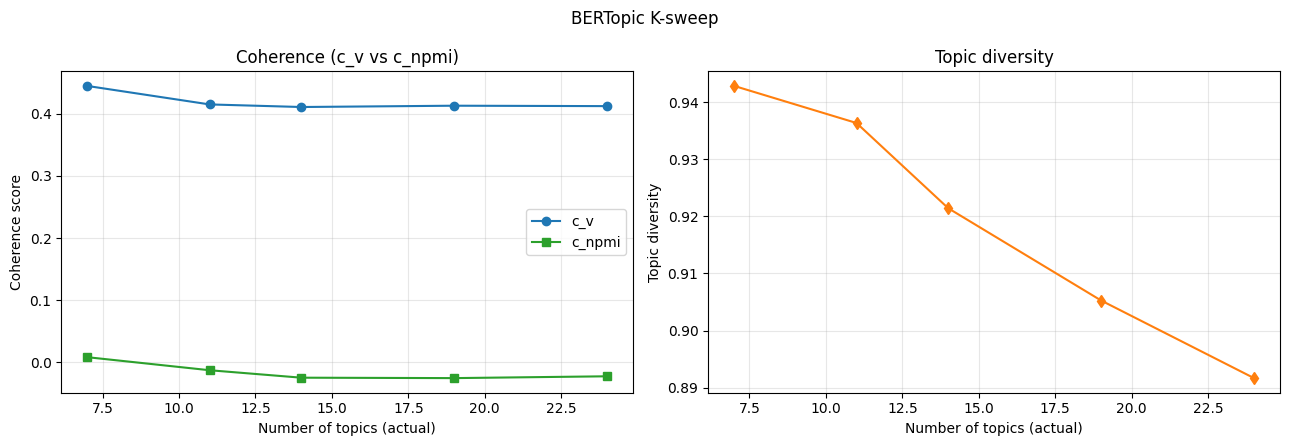


Rekomendasi nr_topics (max combined score): 8
Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(sweep_df['K_actual'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K_actual'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (actual)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['K_actual'], sweep_df['diversity'], 'd-', color='tab:orange')
ax2.set_xlabel('Number of topics (actual)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('BERTopic K-sweep')
fig.tight_layout()
plt.show()

best_idx = sweep_df['combined'].idxmax()
best_k = int(sweep_df.loc[best_idx, 'K_target'])
print(f"\nRekomendasi nr_topics (max combined score): {best_k}")
print("Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.")

## Final Model

In [8]:
NUM_TOPICS = best_k

np.random.seed(SEED)
torch.manual_seed(SEED)

model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=shared_vectorizer,
    nr_topics=NUM_TOPICS,
    min_topic_size=50,
    top_n_words=15,
    calculate_probabilities=True,
    verbose=True,
)
topics, probs = model.fit_transform(docs, embeddings=doc_embeddings)

top_words = bertopic_top_words(model, topn=15)
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal BERTopic | target K={NUM_TOPICS}  actual={len(top_words)}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

bertopic_metrics = {**final_metrics, 'model': 'BERTopic', 'K': len(top_words)}

2026-04-26 07:54:58,172 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 07:55:00,628 - BERTopic - Dimensionality - Completed ✓
2026-04-26 07:55:00,630 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 07:55:02,289 - BERTopic - Cluster - Completed ✓
2026-04-26 07:55:02,290 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-26 07:55:02,425 - BERTopic - Representation - Completed ✓
2026-04-26 07:55:02,425 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 07:55:02,457 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 07:55:02,577 - BERTopic - Representation - Completed ✓
2026-04-26 07:55:02,579 - BERTopic - Topic reduction - Reduced number of topics from 37 to 8



Final BERTopic | target K=8  actual=7  c_v=0.4458  c_npmi=0.0163  diversity=0.9429

Topic 0: game claude agent agents gemini games tools security next real software day fun live something
Topic 1: cursor windsurf agent claude mcp work project file mode copilot something changes feature lovable composer
Topic 2: troll meme coin solana meta coins ppl sell trading btc narrative pump memes launchpad say
Topic 3: doctors practice healthcare practices private health tech services care docs digital cheap compliance nothing entire
Topic 4: kids kid family school child son day days teach learn dad last wife summer little
Topic 5: gpt codex oss claude models gemini best opus openai forth improvements brings previous mac iterate
Topic 6: cooking cooked food cook gon heard amazing let called eating cracked big fire love performance


In [9]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(50)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,11189,-1_tools_day_software_need,"[tools, day, software, need, work, real, somet...",[learning web without reading boring docs real...
1,0,7114,0_game_claude_agent_agents,"[game, claude, agent, agents, gemini, games, t...",[making claude code write blogs since morning ...
2,1,376,1_cursor_windsurf_agent_claude,"[cursor, windsurf, agent, claude, mcp, work, p...","[vibecode privately cursor venice api, feels l..."
3,2,86,2_troll_meme_coin_solana,"[troll, meme, coin, solana, meta, coins, ppl, ...",[outperformed gamblers troll usduc buyign trol...
4,3,78,3_doctors_practice_healthcare_practices,"[doctors, practice, healthcare, practices, pri...",[templates made software practice compliance e...
5,4,77,4_kids_kid_family_school,"[kids, kid, family, school, child, son, day, d...",[teach kids vibecoding must mentor doer assist...
6,5,66,5_gpt_codex_oss_claude,"[gpt, codex, oss, claude, models, gemini, best...",[gpt best coding tested gpt claude gemini usin...
7,6,63,6_cooking_cooked_food_cook,"[cooking, cooked, food, cook, gon, heard, amaz...","[let goooooo cooking vibecoding happy see, vib..."


In [10]:
# Intertopic distance map
fig = model.visualize_topics()
fig.show()

In [11]:
# Top words per topic dengan c-TF-IDF weights
fig = model.visualize_barchart(top_n_topics=min(NUM_TOPICS, 12), n_words=8)
fig.show()

In [12]:
# Hierarchical view
fig = model.visualize_hierarchy()
fig.show()

In [13]:
# Sample tweets per topic untuk inspeksi kualitatif
def sample_docs_for_topic(topic_id, n=3):
    idx = [i for i, t in enumerate(topics) if t == topic_id]
    if not idx:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

# Skip outlier topic -1, ambil top 10 berdasarkan size
non_outlier = topic_info[topic_info['Topic'] != -1].head(10)
for _, row in non_outlier.iterrows():
    tid = row['Topic']
    print(f"\n=== Topic {tid} | size={row['Count']} | {row['Name'][:80]} ===")
    for s in sample_docs_for_topic(tid, n=3):
        print(" -", s[:200])


=== Topic 0 | size=7114 | 0_game_claude_agent_agents ===
 - use llm vibecoding start tools like grok chatgpt claude describe game idea natural language build simple crypto themed puzzle game python refine iteratively based output best results learn basics lang
 - approaching vibecode right way
 - vibecoding show real devex problems windsurf constantly struggles virtual environments python randomly forget venv rabbit hole trying install things

=== Topic 1 | size=376 | 1_cursor_windsurf_agent_claude ===
 - taking part vibecoding hackathon curious workshop hours showing power combining cursor creator hub
 - cursor team vibecode analytics page
 - took cursor vibecoding engineers start taking prds seriously

=== Topic 2 | size=86 | 2_troll_meme_coin_solana ===
 - honestly trev trying understand end goal get attention fud rage bait trying fud every possible competition best strategy stand toxic get true supporters focus
 - else pumpfolio watchlist closer tge
 - meta alchemist explains peop

In [14]:
import os

os.makedirs("artifacts", exist_ok=True)
model.save("artifacts/bertopic_vibecoding", serialization="safetensors", save_ctfidf=True)

assignments = pd.DataFrame({
    "doc": docs,
    "topic_id": topics,
    "topic_prob": probs.max(axis=1) if probs is not None else np.nan,
})
assignments.to_csv("artifacts/bertopic_assignments.csv", index=False)
topic_info.to_csv("artifacts/bertopic_topic_info.csv", index=False)
sweep_df.to_csv("artifacts/bertopic_sweep.csv", index=False)
print("Saved BERTopic artifacts.")

Saved BERTopic artifacts.
